# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3.
    - If $f'(x_0)>0$, move to $x_0-\epsilon$.
    - If $f'(x_0)<0$, move to $x_0+\epsilon$.
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [1]:
import numpy as np

def f(x):
    return x**2 + 6*x + 10
def df(x):
    return 2*x + 6
def gradient_descent(x0, epsilon, iterations):
    x = x0
    for i in range(iterations):

        if df(x) > 0:
            x = x - epsilon
        elif df(x) < 0:
            x = x + epsilon
        else:
            break
    return x

minimum = gradient_descent(10,0.01,1000)

print("Approximate minimum x =", minimum)
print("f(x) =", f(minimum))

Approximate minimum x = 1.6888920817414999e-13
f(x) = 10.000000000001013


### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [3]:
import numpy as np
from scipy.optimize import minimize

def f(x):
    return x**2 + 6*x + 10
def df(x):
    return 2*x + 6
def gradient_descent(x0, epsilon, iterations):
    x = x0
    for i in range(iterations):

        if df(x) > 0:
            x = x - epsilon
        elif df(x) < 0:
            x = x + epsilon
        else:
            break

### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [1]:
import numpy as np
from scipy.optimize import minimize

x = np.array([1,2,3,4,5,6])
y = np.array([2,4,5,4,5,7])

def loss(params):

    m,b = params

    prediction = m*x + b

    return np.sum((y-prediction)**2)

print("Using scipy minimize")
%timeit minimize(loss,[1,1])

print()

print("Using np.polyfit")
%timeit np.polyfit(x,y,1)

result = minimize(loss,[1,1])

m1,b1 = result.x
m2,b2 = np.polyfit(x,y,1)

print()

print("Minimize:")
print("Slope =",m1)
print("Intercept =",b1)

print()

print("Polyfit:")
print("Slope =",m2)
print("Intercept =",b2)

Using scipy minimize
The slowest run took 5.91 times longer than the fastest. This could mean that an intermediate result is being cached.
5.38 ms ± 3.25 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)

Using np.polyfit
53.9 µs ± 17.9 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)

Minimize:
Slope = 0.7714285395419469
Intercept = 1.8000001056359833

Polyfit:
Slope = 0.7714285714285714
Intercept = 1.8000000000000016


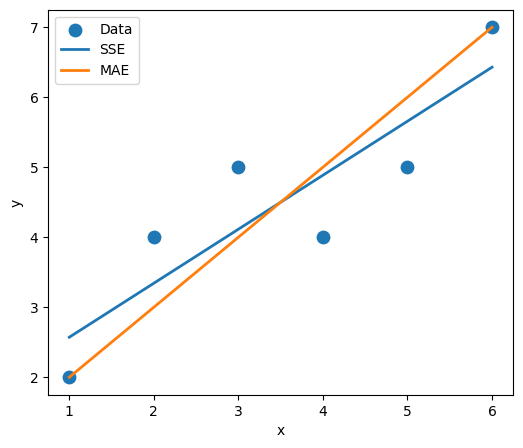

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

x = np.array([1,2,3,4,5,6])
y = np.array([2,4,5,4,5,7])

def loss(params):

    m,b = params

    prediction = m*x+b

    return np.sum((y-prediction)**2)

def loss_2(params):

    m,b = params

    prediction = m*x+b

    return np.sum(np.abs(y-prediction))

result1 = minimize(loss,[1,1])
result2 = minimize(loss_2,[1,1])

m1,b1 = result1.x
m2,b2 = result2.x

plt.figure(figsize=(6,5))

plt.scatter(x,
            y,
            s=80,
            label="Data")

plt.plot(x,
         m1*x+b1,
         linewidth=2,
         label="SSE")

plt.plot(x,
         m2*x+b2,
         linewidth=2,
         label="MAE")

plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.show()

### Problem 4
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.